## libs import

In [9]:
import sqlite3
import pandas as pd

## connection

In [10]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

## queries for date from pageviews and checker for users

In [11]:
query = """
SELECT datetime
FROM pageviews
WHERE uid LIKE 'user_%'; 
"""
df = pd.read_sql_query(query, connection)
df['date'] = pd.to_datetime(df['datetime']).dt.date


In [12]:
daily_views = df.groupby('date').size()
daily_views_df = daily_views.reset_index(name='views')
daily_views_df['date'] = pd.to_datetime(daily_views_df['date'])

In [13]:
query = """
SELECT timestamp AS date
FROM checker
WHERE uid LIKE 'user_%'; 
"""
df = pd.read_sql_query(query, connection)
df['date'] = pd.to_datetime(df['date']).dt.date

In [14]:
daily_commits = df.groupby('date').size()
daily_commits_df = daily_commits.reset_index(name='commits')
daily_commits_df['date'] = pd.to_datetime(daily_commits_df['date'])

## concat dfs

In [15]:
general_df = daily_commits_df.set_index('date', drop=True)
general_df['views'] = daily_views_df.set_index('date', drop=True)['views']

In [20]:
print(daily_views_df.head())
print(daily_commits_df.head())
(general_df.head())

        date  views
0 2020-04-17      1
1 2020-04-18     23
2 2020-04-19     15
3 2020-04-21      3
4 2020-04-22      1
        date  commits
0 2020-04-17       23
1 2020-04-18       69
2 2020-04-19       33
3 2020-04-20       25
4 2020-04-21       25


,commits,views
date,,
2020-04-17,23,1.0
2020-04-18,69,23.0
2020-04-19,33,15.0
2020-04-20,25,NaN
2020-04-21,25,3.0


## Plot. Views and commits per day

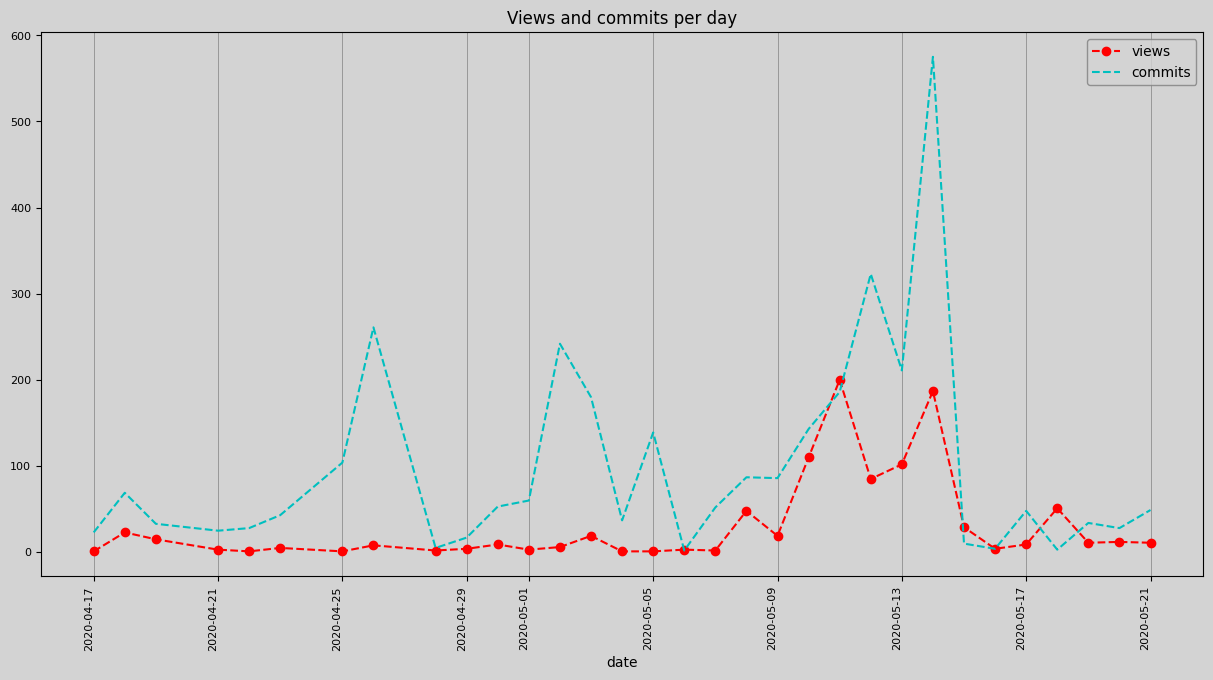

In [23]:
ax = general_df.dropna().plot(y = ['views', 'commits'], use_index=True, figsize=(15, 8), fontsize=8, title="Views and commits per day", 
                style = ['r--o', 'c--'])
ax.tick_params(axis='x', rotation=90)
ax.figure.set_facecolor('lightgray')
ax.set_facecolor('lightgray')
legend = ax.get_legend()
if legend:  # Проверяем, есть ли легенда
    legend.get_frame().set_facecolor('lightgray')  # Заливаем фон легенды серым
    legend.get_frame().set_edgecolor('gray')  # Устанавливаем цвет рамки легенды (опционально)
ax.grid(axis='x', color='gray', linestyle='-', linewidth=0.5)

## Answer for the question:

How many times was the number of views larger than 150?  
The answer is 2.

## connection close

In [24]:
connection.close()